# 06 — Calibration & Validation

**Project:** Explainable Scenario-Based Simulation of Aircraft Damage Consequences Among Reported Wildlife Strikes Using FAA Data

## Main question

**Are the predicted probabilities reliable enough for simulation, and do they generalize to later reporting years and airports not represented during model fitting?**

This notebook consumes the binary modelling artifacts produced by Notebook 05. It does not retune model hyperparameters or redefine the approved predictor lists.

The probability being validated remains:

\[
P(\text{reported aircraft damage} \mid \text{a wildlife strike was reported and the scenario variables})
\]

It is **not** the probability that an ordinary flight experiences a wildlife strike.

### Decisions carried forward from Notebook 05

Notebook 05 established the following design:

- base-model fitting and hyperparameter tuning used only 1990–2018;
- expanding chronological cross-validation was used inside that training period;
- 2019–2021 was the model-selection / validation period;
- 2022–2024 remained completely locked;
- airport-aware XGBoost was the primary calibration candidate;
- extended-geographic XGBoost was retained because the incremental value of `AIRPORT_ID` was small and unseen-airport generalization still needed to be tested;
- logistic regression was retained as an interpretable probability benchmark;
- raw Brier score and log loss were used as probability-quality diagnostics, but calibration was intentionally deferred to this notebook;
- the thresholds explored in Notebook 05 were validation-derived decision policies, not model parameters and not operational safety rules.

### Why calibration is required

Notebook 10 will use the estimated probability directly in Monte Carlo sampling. A model can rank damaging strikes well while still assigning probabilities that are systematically too high or too low. Therefore discrimination alone is insufficient. This notebook evaluates **calibration curves, Brier score, and log loss** and tests both **Platt/sigmoid scaling** and **isotonic calibration**.

### Why calibration selection remains inside 2019–2021

The final test period must not influence the choice of calibrator. Calibration-method selection is therefore performed using forward-year validation within 2019–2021:

1. fit a calibrator on 2019 predictions and evaluate it on 2020;
2. fit a calibrator on 2019–2020 predictions and evaluate it on 2021;
3. pool those forward predictions and compare raw, sigmoid, and isotonic probabilities;
4. lock the calibration method before 2022–2024 is opened;
5. refit the selected calibrator on all 2019–2021 observations.

This mirrors the chronological logic used in Notebook 05 and avoids choosing a calibrator because it happened to perform best on the final test.

### Why thresholds are explored again after calibration

Calibration changes the numerical probability scale. A raw-model threshold such as `0.2619` from Notebook 05 is therefore not automatically the corresponding cutoff after calibration.

Thresholds are re-estimated only from **forward-calibrated 2019–2021 predictions**. The notebook keeps the same interpretations used in Notebook 05:

- maximum F1: balanced precision/recall reference;
- maximum F2: recall-sensitive reference;
- highest precision while obtaining at least 70% recall;
- highest precision while obtaining at least 80% recall.

These are analytical sensitivity points, not operational recommendations. A real operating threshold would require explicit costs for false negatives and false positives.

### Geographic decision before opening the final test

Notebook 05 found only a small overall validation gain from exact airport identity. Before calibration is locked, this notebook therefore compares the airport-aware and extended-geographic XGBoost candidates on the subset of 2019–2021 incidents occurring at airports absent from the 1990–2018 fitting period.

The extended-geographic fallback is promoted only when:

- the unseen-airport subset contains enough observations and positive cases to be interpretable;
- it has **both** higher PR-AUC and lower Brier score on that unseen-airport subset; and
- its overall 2019–2021 PR-AUC remains within 1% relative of the airport-aware candidate.

This is a transparent dominance rule rather than a test-set-driven switch. If those conditions are not jointly met, the Notebook-05 primary airport-aware candidate remains the selected base model.

## 1. Expected repository structure and inputs

The notebook expects the same portable repository structure used by Notebook 05:

```text
project/
├── data/
│   └── processed/
│       └── faa_strikes_binary_model_ready.csv
├── docs/
│   └── feature_lists.json
├── models/
│   ├── candidates/
│   │   ├── xgboost__airport_aware_uncalibrated.joblib
│   │   ├── xgboost__extended_geographic_uncalibrated.joblib
│   │   └── logistic__..._uncalibrated.joblib
│   └── final/
│       └── final_calibrated_pipeline.joblib
├── notebooks/
│   └── 06_calibration_validation.ipynb
└── outputs/
    └── 06_calibration_validation/
```

The `models/candidates/` files are intermediate artifacts produced by Notebook 05. This notebook writes the single downstream model artifact to `models/final/`.

If the candidate model files are missing, rerun Notebook 05 first. The code below deliberately does **not** silently retrain or retune them because doing so would blur the boundary between the modelling and validation stages.

In [1]:
from pathlib import Path
import json
import warnings
import sys
import platform

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn import __version__ as sklearn_version
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

try:
    from sklearn.frozen import FrozenEstimator
    HAS_FROZEN_ESTIMATOR = True
except ImportError:
    FrozenEstimator = None
    HAS_FROZEN_ESTIMATOR = False

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)

SEED = 42
np.random.seed(SEED)

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn_version)
print("FrozenEstimator available:", HAS_FROZEN_ESTIMATOR)

Python: 3.12.9
scikit-learn: 1.7.0
FrozenEstimator available: True


In [2]:
# Locate the repository root without machine-specific absolute paths.
ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data").exists() or (candidate / "models").exists():
        ROOT = candidate
        break

PROCESSED_DIR = ROOT / "data" / "processed"
OUTPUT_DIR = ROOT / "outputs" / "06_calibration_validation"
CANDIDATE_MODEL_DIR = ROOT / "models" / "candidates"
FINAL_MODEL_DIR = ROOT / "models" / "final"
DOCS_DIR = ROOT / "docs"

for directory in [OUTPUT_DIR, FINAL_MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

data_candidates = [
    PROCESSED_DIR / "faa_strikes_binary_model_ready.csv",
    PROCESSED_DIR / "faa_strikes_binary_model.csv",
    ROOT / "faa_strikes_binary_model_ready.csv",
    ROOT / "faa_strikes_binary_model.csv",
    Path("/mnt/data/faa_strikes_binary_model_ready(1).csv"),
]

DATA_PATH = next((p for p in data_candidates if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "No readable binary modelling dataset was found. Run Notebook 05 or "
        "place faa_strikes_binary_model_ready.csv in data/processed/."
    )

print("Repository root:", ROOT)
print("Data:", DATA_PATH)
print("Candidate models:", CANDIDATE_MODEL_DIR)
print("Final model directory:", FINAL_MODEL_DIR)
print("Outputs:", OUTPUT_DIR)

Repository root: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis
Data: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\data\processed\faa_strikes_binary_model_ready.csv
Candidate models: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\models\candidates
Final model directory: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\models\final
Outputs: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\outputs\06_calibration_validation


### Execution note for this delivered notebook

This notebook can read the uploaded `faa_strikes_binary_model_ready` CSV, but the serialized candidate pipelines from Notebook 05 were not supplied with the current files. Therefore the calibration and final-validation cells are intentionally left unexecuted here.

Run Notebook 05 locally first so that `models/candidates/` contains its fitted pipelines, then run this notebook from the top in a fresh kernel. The cells fail clearly when a required candidate artifact is absent rather than substituting a newly trained model.

In [3]:
df = pd.read_csv(DATA_PATH, low_memory=False)

required_columns = {
    "INDICATED_DAMAGE",
    "TEMPORAL_SPLIT",
    "INCIDENT_YEAR",
    "INDEX_NR",
    "AIRPORT_ID",
}
missing_required = sorted(required_columns - set(df.columns))
assert not missing_required, f"Missing required columns: {missing_required}"

assert df["INDICATED_DAMAGE"].notna().all()
assert set(df["INDICATED_DAMAGE"].astype(int).unique()).issubset({0, 1})
assert df["INDEX_NR"].is_unique, "INDEX_NR should identify one retained incident."

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())

Rows: 319,107
Columns: 25


,INDICATED_DAMAGE,SEASON,MONTH_SIN,MONTH_COS,WILDLIFE_TYPE,SIZE,NUM_STRUCK,AC_CLASS,AC_MASS_GROUP,TYPE_ENG,NUM_ENGS,WARNED,PHASE_OF_FLIGHT,HEIGHT,SPEED,TIME_OF_DAY,SKY,PRECIPITATION,STATE,FAAREGION,AIRPORT_ID,TEMPORAL_SPLIT,INCIDENT_YEAR,INDEX_NR,TARGET_CONFLICT_FLAG
0,0,Summer,1.224647e-16,-1.000000,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,CA,AWP,KSMF,train_1990_2018,1996,608242,0
1,0,Summer,1.224647e-16,-1.000000,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,CO,ANM,KDEN,train_1990_2018,1996,608243,0
2,0,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Take-off Run,0.0,NaN,Not reported,Not reported,Not reported,NE,ACE,KOMA,train_1990_2018,1996,608244,0
3,0,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Approach,1000.0,NaN,Not reported,Not reported,Not reported,DC,AEA,KIAD,train_1990_2018,1996,608245,0
4,1,Summer,-5.000000e-01,-0.866025,Bird,Medium,1,A,Heavy,D,2.0,Unknown,Climb,5000.0,NaN,Not reported,Not reported,Not reported,NY,AEA,KLGA,train_1990_2018,1996,608246,0


## 2. Reconfirm the locked partitions without opening the final-test results

The split definitions are checked now, but the 2022–2024 labels are not evaluated until the final-test section. All model, geographic, calibration, and threshold decisions must be completed first.

In [4]:
train_mask = df["TEMPORAL_SPLIT"].eq("train_1990_2018")
validation_mask = df["TEMPORAL_SPLIT"].eq("validation_2019_2021")
test_mask = df["TEMPORAL_SPLIT"].eq("test_2022_2024")

assert not (train_mask & validation_mask).any()
assert not (train_mask & test_mask).any()
assert not (validation_mask & test_mask).any()

partition_structure = pd.DataFrame([
    {
        "partition": "training",
        "expected_years": "1990–2018",
        "rows": int(train_mask.sum()),
        "first_year": int(df.loc[train_mask, "INCIDENT_YEAR"].min()),
        "last_year": int(df.loc[train_mask, "INCIDENT_YEAR"].max()),
        "role_in_notebook06": "Reference fitted-model training population",
        "outcomes_evaluated_before_final_section": False,
    },
    {
        "partition": "validation/calibration",
        "expected_years": "2019–2021",
        "rows": int(validation_mask.sum()),
        "first_year": int(df.loc[validation_mask, "INCIDENT_YEAR"].min()),
        "last_year": int(df.loc[validation_mask, "INCIDENT_YEAR"].max()),
        "role_in_notebook06": "Geographic decision, calibrator selection, threshold selection",
        "outcomes_evaluated_before_final_section": True,
    },
    {
        "partition": "locked final test",
        "expected_years": "2022–2024",
        "rows": int(test_mask.sum()),
        "first_year": int(df.loc[test_mask, "INCIDENT_YEAR"].min()),
        "last_year": int(df.loc[test_mask, "INCIDENT_YEAR"].max()),
        "role_in_notebook06": "One-time final generalization assessment",
        "outcomes_evaluated_before_final_section": False,
    },
])

display(partition_structure)

,partition,expected_years,rows,first_year,last_year,role_in_notebook06,outcomes_evaluated_before_final_section
0,training,1990–2018,215274,1990,2018,Reference fitted-model training population,False
1,validation/calibration,2019–2021,44614,2019,2021,"Geographic decision, calibrator selection, thr...",True
2,locked final test,2022–2024,59219,2022,2024,One-time final generalization assessment,False


## 3. Load Notebook-05 feature metadata and candidate manifest

Notebook 06 does not create an independent predictor list. When available, it reads the canonical `feature_lists.json`; otherwise it uses the same verified fallback list embedded in Notebook 05 and emits a warning.

The preferred source for model paths is `outputs/05_damage_modelling/uncalibrated_candidate_manifest.csv`. If that manifest is absent, the notebook searches `models/candidates/` using the filenames written by Notebook 05.

In [5]:
fallback_feature_lists = {
    "core_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED"
    ],
    "extended_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED", "PHASE_OF_FLIGHT", "HEIGHT", "SPEED",
        "TIME_OF_DAY", "SKY", "PRECIPITATION", "STATE", "FAAREGION"
    ],
    "airport_aware_features": [
        "SEASON", "MONTH_SIN", "MONTH_COS", "WILDLIFE_TYPE", "SIZE",
        "NUM_STRUCK", "AC_CLASS", "AC_MASS_GROUP", "TYPE_ENG",
        "NUM_ENGS", "WARNED", "PHASE_OF_FLIGHT", "HEIGHT", "SPEED",
        "TIME_OF_DAY", "SKY", "PRECIPITATION", "STATE", "FAAREGION",
        "AIRPORT_ID"
    ],
    "primary_target": "INDICATED_DAMAGE",
    "seed": SEED,
}

feature_list_path = DOCS_DIR / "feature_lists.json"
if feature_list_path.exists():
    with open(feature_list_path, "r", encoding="utf-8") as f:
        feature_lists = json.load(f)
else:
    feature_lists = fallback_feature_lists.copy()
    warnings.warn(
        "docs/feature_lists.json not found. Using the same verified fallback "
        "embedded in Notebook 05. Regenerate the canonical JSON before submission."
    )

TARGET = feature_lists.get("primary_target", "INDICATED_DAMAGE")
EXTENDED_FEATURES = [
    c for c in feature_lists["extended_features"] if c in df.columns
]
AIRPORT_AWARE_FEATURES = [
    c for c in feature_lists["airport_aware_features"] if c in df.columns
]

assert "AIRPORT_ID" not in EXTENDED_FEATURES
assert "AIRPORT_ID" in AIRPORT_AWARE_FEATURES

feature_summary = pd.DataFrame([
    {
        "feature_set": "extended_geographic",
        "n_features": len(EXTENDED_FEATURES),
        "includes_airport_id": False,
    },
    {
        "feature_set": "airport_aware",
        "n_features": len(AIRPORT_AWARE_FEATURES),
        "includes_airport_id": True,
    },
])
display(feature_summary)

,feature_set,n_features,includes_airport_id
0,extended_geographic,19,False
1,airport_aware,20,True


In [6]:
NOTEBOOK05_OUTPUT_DIR = ROOT / "outputs" / "05_damage_modelling"
manifest_path = NOTEBOOK05_OUTPUT_DIR / "uncalibrated_candidate_manifest.csv"

if manifest_path.exists():
    candidate_manifest = pd.read_csv(manifest_path)
else:
    discovered = sorted(CANDIDATE_MODEL_DIR.glob("*_uncalibrated.joblib"))
    candidate_manifest = pd.DataFrame({
        "candidate": [p.name.replace("_uncalibrated.joblib", "") for p in discovered],
        "path": [str(p) for p in discovered],
    })
    if not candidate_manifest.empty:
        warnings.warn(
            "Notebook-05 candidate manifest was not found. Candidate files were "
            "discovered directly from models/candidates/."
        )

display(candidate_manifest)

required_candidate_names = {
    "xgboost__airport_aware",
    "xgboost__extended_geographic",
}
available_candidates = set(candidate_manifest.get("candidate", pd.Series(dtype=str)))

missing_candidates = sorted(required_candidate_names - available_candidates)
if missing_candidates:
    raise FileNotFoundError(
        "Required Notebook-05 candidate pipelines are missing: "
        f"{missing_candidates}. Rerun Notebook 05 before executing Notebook 06."
    )

,candidate,path,selected_for_primary_calibration,file_size_mb
0,logistic__extended_geographic,c:\Users\davis\Programing\MDA_programs\Capston...,False,0.011282
1,random_forest__extended_geographic,c:\Users\davis\Programing\MDA_programs\Capston...,False,498.607509
2,xgboost__extended_geographic,c:\Users\davis\Programing\MDA_programs\Capston...,False,2.143913
3,logistic__airport_aware,c:\Users\davis\Programing\MDA_programs\Capston...,False,0.063669
4,random_forest__airport_aware,c:\Users\davis\Programing\MDA_programs\Capston...,False,426.901942
5,xgboost__airport_aware,c:\Users\davis\Programing\MDA_programs\Capston...,True,1.877616


In [7]:
def resolve_candidate_path(candidate_name):
    row = candidate_manifest.loc[
        candidate_manifest["candidate"].eq(candidate_name)
    ]
    if row.empty:
        return None

    manifest_value = Path(str(row.iloc[0]["path"]))
    path_options = [
        manifest_value,
        ROOT / manifest_value,
        CANDIDATE_MODEL_DIR / f"{candidate_name}_uncalibrated.joblib",
    ]
    return next((p for p in path_options if p.exists()), None)


candidate_models = {}
for candidate_name in sorted(available_candidates):
    if not (
        candidate_name.startswith("xgboost__")
        or candidate_name.startswith("logistic__")
    ):
        continue

    model_path = resolve_candidate_path(candidate_name)
    if model_path is not None:
        candidate_models[candidate_name] = joblib.load(model_path)

print("Loaded candidate pipelines:")
for name in candidate_models:
    print(" -", name)

assert "xgboost__airport_aware" in candidate_models
assert "xgboost__extended_geographic" in candidate_models

Loaded candidate pipelines:
 - logistic__airport_aware
 - logistic__extended_geographic
 - xgboost__airport_aware
 - xgboost__extended_geographic


## 4. Evaluation helpers

Three distinct questions are kept separate:

1. **Discrimination** — can the model rank damaging incidents above non-damaging incidents?  
   Main measure: PR-AUC; ROC-AUC is supporting evidence.

2. **Probability quality / calibration** — do predicted probabilities correspond to observed frequencies?  
   Measures: Brier score, log loss, and calibration curves.

3. **Binary operating behavior** — what happens after applying a chosen decision threshold?  
   Measures: precision, recall, F1/F2, confusion matrices.

This separation is important because a model can have strong discrimination but poor probability calibration, and a threshold can change precision/recall without changing PR-AUC.

In [8]:
def probability_metrics(y_true, probabilities):
    probabilities = np.asarray(probabilities, dtype=float)
    probabilities = np.clip(probabilities, 1e-12, 1 - 1e-12)
    return {
        "n": int(len(y_true)),
        "positives": int(np.sum(y_true)),
        "prevalence": float(np.mean(y_true)),
        "pr_auc": average_precision_score(y_true, probabilities),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
        "log_loss": log_loss(y_true, probabilities, labels=[0, 1]),
        "mean_predicted_probability": float(np.mean(probabilities)),
    }


def threshold_metrics(y_true, probabilities, threshold):
    pred = (np.asarray(probabilities) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def choose_thresholds(y_true, probabilities):
    probabilities = np.asarray(probabilities)
    thresholds = np.unique(
        np.quantile(probabilities, np.linspace(0, 1, 1001))
    )

    rows = []
    for threshold in thresholds:
        rows.append(threshold_metrics(y_true, probabilities, threshold))

    table = pd.DataFrame(rows)

    selections = []

    f1_row = table.sort_values(
        ["f1", "recall", "precision"],
        ascending=[False, False, False]
    ).iloc[0]
    selections.append(("maximum_validation_f1", f1_row))

    f2_row = table.sort_values(
        ["f2", "recall", "precision"],
        ascending=[False, False, False]
    ).iloc[0]
    selections.append(("maximum_validation_f2_sensitivity", f2_row))

    for target_recall in [0.70, 0.80]:
        eligible = table.loc[table["recall"] >= target_recall]
        if not eligible.empty:
            best = eligible.sort_values(
                ["precision", "recall", "threshold"],
                ascending=[False, False, False]
            ).iloc[0]
            selections.append((
                f"highest_precision_at_recall_{int(target_recall * 100)}",
                best
            ))

    output = []
    for rule, row in selections:
        record = row.to_dict()
        record["rule"] = rule
        output.append(record)

    return pd.DataFrame(output)[[
        "rule", "threshold", "precision", "recall", "f1", "f2",
        "tn", "fp", "fn", "tp"
    ]]

## 5. Geographic generalization gate using 2019–2021 only

An airport-aware model may benefit from persistent airport-specific patterns, but exact airport identity can also encourage memorization. Notebook 05 showed that `AIRPORT_ID` added only a small aggregate validation improvement for XGBoost, so this notebook checks whether that benefit survives when the validation record comes from an airport absent from the 1990–2018 base-model fitting period.

This is a **chronological unseen-airport test**, not a random grouped split. It therefore preserves the project's future-facing validation logic.

The final 2022–2024 period is still locked.

In [9]:
training_airports = set(
    df.loc[train_mask, "AIRPORT_ID"]
      .dropna()
      .astype(str)
      .unique()
)

validation_airport_values = (
    df.loc[validation_mask, "AIRPORT_ID"]
      .astype("string")
)

validation_unseen_airport_mask = (
    validation_mask
    & ~df["AIRPORT_ID"].astype("string").isin(training_airports)
)

unseen_summary = pd.DataFrame([{
    "validation_rows": int(validation_mask.sum()),
    "unseen_airport_rows": int(validation_unseen_airport_mask.sum()),
    "unseen_airport_share": (
        validation_unseen_airport_mask.sum() / validation_mask.sum()
    ),
    "unseen_airport_positive_cases": int(
        df.loc[validation_unseen_airport_mask, TARGET].sum()
    ),
    "unique_unseen_airports": int(
        df.loc[validation_unseen_airport_mask, "AIRPORT_ID"].nunique()
    ),
}])

display(unseen_summary.round(4))

,validation_rows,unseen_airport_rows,unseen_airport_share,unseen_airport_positive_cases,unique_unseen_airports
0,44614,212,0.0048,84,152


In [10]:
unseen_airport_diagnostic = (
    df.loc[validation_unseen_airport_mask]
    .groupby("AIRPORT_ID")[TARGET]
    .agg(
        records="size",
        damage_cases="sum",
        damage_rate="mean",
    )
    .sort_values(
        ["records", "damage_cases"],
        ascending=False
    )
)

display(unseen_airport_diagnostic.head(25))

unseen_airport_diagnostic.to_csv(
    OUTPUT_DIR / "validation_unseen_airport_diagnostic.csv"
)

,records,damage_cases,damage_rate
AIRPORT_ID,,,
KXWA,34,0,0.000000
65NJ,4,3,0.750000
KEHO,3,2,0.666667
KCFO,3,0,0.000000
1S9,2,2,1.000000
71J,2,2,1.000000
99CL,2,2,1.000000
KCKI,2,2,1.000000
42A,2,1,0.500000


The unseen-airport validation subset has a much higher damage prevalence than the overall validation population, so its composition was inspected before interpreting model performance. The elevated prevalence does not appear to be driven by one dominant high-damage airport. Instead, many of the unseen airport codes contain only one or a few observations, and several of these very small groups have high observed damage rates. For example, the largest unseen airport group, KXWA, contains 34 records with no reported damage, whereas several airport codes with one to four records contain one or more damage cases.

This confirms that the unseen-airport subset is highly sparse and heterogeneous. Its aggregate performance metrics should therefore be interpreted cautiously and should not be taken as representative of performance at a typical new airport. This diagnostic is descriptive only and does not alter the predefined geographic model-selection rule.

In [11]:
geo_candidate_specs = {
    "xgboost__airport_aware": AIRPORT_AWARE_FEATURES,
    "xgboost__extended_geographic": EXTENDED_FEATURES,
}

geo_rows = []
geo_probability_store = {}

for candidate_name, features in geo_candidate_specs.items():
    model = candidate_models[candidate_name]

    for subset_name, mask in {
        "validation_all": validation_mask,
        "validation_unseen_airports": validation_unseen_airport_mask,
    }.items():
        X = df.loc[mask, features]
        y = df.loc[mask, TARGET].astype(int)

        if len(y) == 0 or y.nunique() < 2:
            warnings.warn(
                f"{candidate_name} / {subset_name} does not contain both classes."
            )
            continue

        prob = model.predict_proba(X)[:, 1]
        geo_probability_store[(candidate_name, subset_name)] = prob

        geo_rows.append({
            "candidate": candidate_name,
            "subset": subset_name,
            **probability_metrics(y, prob),
        })

geo_comparison = pd.DataFrame(geo_rows)
geo_comparison.to_csv(
    OUTPUT_DIR / "geographic_generalization_validation.csv",
    index=False
)
display(geo_comparison.round(5))

,candidate,subset,n,positives,prevalence,pr_auc,roc_auc,brier_score,log_loss,mean_predicted_probability
0,xgboost__airport_aware,validation_all,44614,1925,0.04315,0.44960,0.90615,0.03052,0.11517,0.05286
1,xgboost__airport_aware,validation_unseen_airports,212,84,0.39623,0.73793,0.85091,0.16887,0.49980,0.33099
2,xgboost__extended_geographic,validation_all,44614,1925,0.04315,0.44817,0.90523,0.03058,0.11527,0.05201
3,xgboost__extended_geographic,validation_unseen_airports,212,84,0.39623,0.76333,0.85454,0.17463,0.51617,0.29653


In [12]:
MIN_UNSEEN_ROWS = 1000
MIN_UNSEEN_POSITIVES = 50
RELATIVE_PR_AUC_TOLERANCE = 0.01

unseen_n = int(validation_unseen_airport_mask.sum())
unseen_pos = int(df.loc[validation_unseen_airport_mask, TARGET].sum())

airport_all = geo_comparison.query(
    "candidate == 'xgboost__airport_aware' and subset == 'validation_all'"
).iloc[0]
extended_all = geo_comparison.query(
    "candidate == 'xgboost__extended_geographic' and subset == 'validation_all'"
).iloc[0]

airport_unseen = geo_comparison.query(
    "candidate == 'xgboost__airport_aware' and subset == 'validation_unseen_airports'"
).iloc[0]
extended_unseen = geo_comparison.query(
    "candidate == 'xgboost__extended_geographic' and subset == 'validation_unseen_airports'"
).iloc[0]

adequate_unseen_support = (
    unseen_n >= MIN_UNSEEN_ROWS
    and unseen_pos >= MIN_UNSEEN_POSITIVES
)

extended_dominates_unseen = (
    extended_unseen["pr_auc"] > airport_unseen["pr_auc"]
    and extended_unseen["brier_score"] < airport_unseen["brier_score"]
)

extended_overall_close = (
    extended_all["pr_auc"]
    >= (1 - RELATIVE_PR_AUC_TOLERANCE) * airport_all["pr_auc"]
)

promote_extended = (
    adequate_unseen_support
    and extended_dominates_unseen
    and extended_overall_close
)

if promote_extended:
    SELECTED_BASE_KEY = "xgboost__extended_geographic"
    SELECTED_FEATURES = EXTENDED_FEATURES
    geographic_decision = (
        "Promote extended-geographic XGBoost because it dominates the "
        "airport-aware model on supported unseen-airport validation while "
        "remaining within 1% relative PR-AUC overall."
    )
else:
    SELECTED_BASE_KEY = "xgboost__airport_aware"
    SELECTED_FEATURES = AIRPORT_AWARE_FEATURES
    geographic_decision = (
        "Retain Notebook-05 airport-aware XGBoost because the predefined "
        "conditions for geographic fallback were not all satisfied."
    )

geographic_decision_df = pd.DataFrame([{
    "selected_base_candidate": SELECTED_BASE_KEY,
    "adequate_unseen_support": adequate_unseen_support,
    "extended_dominates_unseen": extended_dominates_unseen,
    "extended_overall_within_1pct_relative_pr_auc": extended_overall_close,
    "decision": geographic_decision,
    "final_test_used": False,
}])

geographic_decision_df.to_csv(
    OUTPUT_DIR / "geographic_model_decision.csv",
    index=False
)
display(geographic_decision_df)

,selected_base_candidate,adequate_unseen_support,extended_dominates_unseen,extended_overall_within_1pct_relative_pr_auc,decision,final_test_used
0,xgboost__airport_aware,False,False,True,Retain Notebook-05 airport-aware XGBoost becau...,False


### Geographic-decision interpretation

The unseen-airport validation subset contained 212 incidents from airports absent from the 1990–2018 base-model training period, including 84 reported-damage cases. On the full 2019–2021 validation period, the airport-aware XGBoost achieved a PR-AUC of 0.4496 and a Brier score of 0.03052, compared with a PR-AUC of 0.4482 and Brier score of 0.03058 for the extended-geographic model.

On the unseen-airport subset, the extended-geographic model achieved the higher PR-AUC (0.7633 versus 0.7379), indicating somewhat stronger discrimination in this subset. However, its Brier score was worse (0.17463 versus 0.16887), so it did not simultaneously improve both ranking and probability quality. In addition, the unseen-airport sample contained only 212 observations and did not meet the predefined support threshold for promoting the fallback model.

Accordingly, the predefined fallback conditions were not jointly satisfied, and the airport-aware XGBoost remained the selected base candidate before the 2022–2024 final test was opened. This result does not establish that airport identity is universally beneficial; it only indicates that the available validation evidence was insufficient to justify replacing the Notebook-05 primary candidate.


## 6. Forward-year calibration experiment inside 2019–2021

### Calibration methods

- **Raw / identity:** no probability correction. It is included so calibration is not forced when both calibration methods worsen probability quality.
- **Sigmoid (Platt-style) calibration:** fits a logistic mapping and is usually smoother and less flexible.
- **Isotonic calibration:** fits a monotonic non-parametric mapping and can correct more complex miscalibration, but it can overfit when calibration data are limited.

The method is selected by pooled forward-year **Brier score**, with log loss as the secondary criterion and PR-AUC reported as a consistency check. Calibration should usually preserve ranking, although isotonic ties can cause small PR-AUC changes.

The final test is still locked.

In [13]:
selected_base_model = candidate_models[SELECTED_BASE_KEY]

validation_years = sorted(
    df.loc[validation_mask, "INCIDENT_YEAR"].dropna().astype(int).unique()
)
assert validation_years == [2019, 2020, 2021], (
    f"Expected validation years 2019–2021, found {validation_years}"
)

# Cache the selected base model's raw validation probabilities.
X_validation_all = df.loc[validation_mask, SELECTED_FEATURES]
y_validation_all = df.loc[validation_mask, TARGET].astype(int)
raw_validation_prob = selected_base_model.predict_proba(X_validation_all)[:, 1]

validation_prediction_frame = df.loc[
    validation_mask,
    ["INDEX_NR", "INCIDENT_YEAR", TARGET, "AIRPORT_ID"]
].copy()
validation_prediction_frame["raw_probability"] = raw_validation_prob

display(validation_prediction_frame.head())

,INDEX_NR,INCIDENT_YEAR,INDICATED_DAMAGE,AIRPORT_ID,raw_probability
179707,817858,2019,0,PHLI,0.009113
179708,817859,2019,0,KATL,0.000373
179709,817860,2019,0,KMCI,0.000883
179710,817861,2019,0,KBMI,0.000889
179711,817864,2019,0,KLAX,0.061275


In [14]:
def make_prefit_calibrator(base_model, method):
    """Create a calibrator without refitting the Notebook-05 base estimator."""
    if HAS_FROZEN_ESTIMATOR:
        return CalibratedClassifierCV(
            estimator=FrozenEstimator(base_model),
            method=method,
        )

    warnings.warn(
        "FrozenEstimator is unavailable in this scikit-learn version. "
        "Using cv='prefit' compatibility mode. Consider upgrading scikit-learn "
        "before final submission because cv='prefit' is deprecated in newer releases."
    )
    return CalibratedClassifierCV(
        estimator=base_model,
        method=method,
        cv="prefit",
    )

In [15]:
forward_calibration_rows = []
forward_prediction_parts = []

calibration_folds = [
    {
        "fold": 1,
        "calibration_years": [2019],
        "evaluation_year": 2020,
    },
    {
        "fold": 2,
        "calibration_years": [2019, 2020],
        "evaluation_year": 2021,
    },
]

for spec in calibration_folds:
    calibration_mask = (
        validation_mask
        & df["INCIDENT_YEAR"].isin(spec["calibration_years"])
    )
    evaluation_mask = (
        validation_mask
        & df["INCIDENT_YEAR"].eq(spec["evaluation_year"])
    )

    X_cal = df.loc[calibration_mask, SELECTED_FEATURES]
    y_cal = df.loc[calibration_mask, TARGET].astype(int)
    X_eval = df.loc[evaluation_mask, SELECTED_FEATURES]
    y_eval = df.loc[evaluation_mask, TARGET].astype(int)

    raw_eval_prob = selected_base_model.predict_proba(X_eval)[:, 1]

    fold_prediction = df.loc[
        evaluation_mask,
        ["INDEX_NR", "INCIDENT_YEAR", TARGET, "AIRPORT_ID"]
    ].copy()
    fold_prediction["fold"] = spec["fold"]
    fold_prediction["raw_probability"] = raw_eval_prob

    forward_calibration_rows.append({
        "fold": spec["fold"],
        "calibration_method": "raw",
        "calibration_years": ",".join(map(str, spec["calibration_years"])),
        "evaluation_year": spec["evaluation_year"],
        **probability_metrics(y_eval, raw_eval_prob),
    })

    for sklearn_method, label in [
        ("sigmoid", "sigmoid_platt"),
        ("isotonic", "isotonic"),
    ]:
        calibrator = make_prefit_calibrator(
            selected_base_model,
            sklearn_method
        )
        calibrator.fit(X_cal, y_cal)
        calibrated_prob = calibrator.predict_proba(X_eval)[:, 1]

        fold_prediction[f"{label}_probability"] = calibrated_prob

        forward_calibration_rows.append({
            "fold": spec["fold"],
            "calibration_method": label,
            "calibration_years": ",".join(map(str, spec["calibration_years"])),
            "evaluation_year": spec["evaluation_year"],
            **probability_metrics(y_eval, calibrated_prob),
        })

    forward_prediction_parts.append(fold_prediction)

forward_calibration_metrics = pd.DataFrame(forward_calibration_rows)
forward_calibration_predictions = pd.concat(
    forward_prediction_parts, ignore_index=True
)

forward_calibration_metrics.to_csv(
    OUTPUT_DIR / "forward_calibration_fold_metrics.csv",
    index=False
)
forward_calibration_predictions.to_csv(
    OUTPUT_DIR / "forward_calibration_predictions.csv",
    index=False
)

display(forward_calibration_metrics.round(5))

,fold,calibration_method,calibration_years,evaluation_year,n,positives,prevalence,pr_auc,roc_auc,brier_score,log_loss,mean_predicted_probability
0,1,raw,2019,2020,11625,493,0.04241,0.43611,0.91328,0.03040,0.11307,0.05362
1,1,sigmoid_platt,2019,2020,11625,493,0.04241,0.43611,0.91328,0.03136,0.12386,0.04448
2,1,isotonic,2019,2020,11625,493,0.04241,0.40846,0.91132,0.03023,0.11404,0.04414
3,2,raw,"2019,2020",2021,15641,667,0.04264,0.45402,0.90752,0.03029,0.11400,0.05068
4,2,sigmoid_platt,"2019,2020",2021,15641,667,0.04264,0.45402,0.90752,0.03140,0.12577,0.04114
5,2,isotonic,"2019,2020",2021,15641,667,0.04264,0.43034,0.90651,0.03026,0.11345,0.04045


In [16]:
pooled_method_rows = []
y_forward = forward_calibration_predictions[TARGET].astype(int)

for method, col in {
    "raw": "raw_probability",
    "sigmoid_platt": "sigmoid_platt_probability",
    "isotonic": "isotonic_probability",
}.items():
    pooled_method_rows.append({
        "calibration_method": method,
        **probability_metrics(
            y_forward,
            forward_calibration_predictions[col].to_numpy()
        ),
    })

pooled_calibration_results = (
    pd.DataFrame(pooled_method_rows)
      .sort_values(
          ["brier_score", "log_loss", "pr_auc"],
          ascending=[True, True, False]
      )
      .reset_index(drop=True)
)

SELECTED_CALIBRATION_METHOD = pooled_calibration_results.iloc[0][
    "calibration_method"
]

pooled_calibration_results["selected"] = (
    pooled_calibration_results["calibration_method"]
    .eq(SELECTED_CALIBRATION_METHOD)
)

pooled_calibration_results.to_csv(
    OUTPUT_DIR / "calibration_method_selection.csv",
    index=False
)

display(pooled_calibration_results.round(5))
print("Selected calibration method:", SELECTED_CALIBRATION_METHOD)
print("Final test used for calibration selection: False")

,calibration_method,n,positives,prevalence,pr_auc,roc_auc,brier_score,log_loss,mean_predicted_probability,selected
0,isotonic,27266,1160,0.04254,0.42183,0.90763,0.03025,0.11370,0.04203,True
1,raw,27266,1160,0.04254,0.44484,0.90991,0.03033,0.11360,0.05194,False
2,sigmoid_platt,27266,1160,0.04254,0.44291,0.90980,0.03138,0.12495,0.04257,False


Selected calibration method: isotonic
Final test used for calibration selection: False


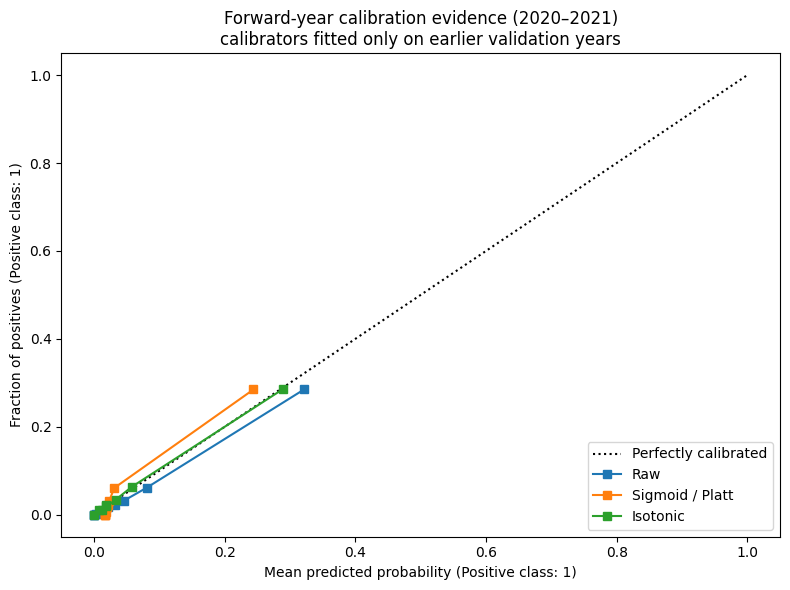

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))

for label, col in {
    "Raw": "raw_probability",
    "Sigmoid / Platt": "sigmoid_platt_probability",
    "Isotonic": "isotonic_probability",
}.items():
    CalibrationDisplay.from_predictions(
        y_forward,
        forward_calibration_predictions[col],
        n_bins=10,
        strategy="quantile",
        name=label,
        ax=ax,
    )

ax.set_title(
    "Forward-year calibration evidence (2020–2021)\n"
    "calibrators fitted only on earlier validation years"
)
plt.tight_layout()
plt.show()

### Calibration-method interpretation 

Across the pooled forward-year calibration evaluation for 2020–2021, isotonic calibration produced the lowest Brier score at 0.03025, compared with 0.03033 for the raw probabilities and 0.03138 for sigmoid/Platt calibration. The improvement over the raw model was therefore small, approximately 0.00008 in absolute Brier score.

Log loss did not produce exactly the same ordering. The raw model achieved the lowest log loss at 0.11360, followed very closely by isotonic calibration at 0.11370, while sigmoid calibration was worse at 0.12495. Therefore, isotonic calibration slightly improved the primary Brier-score criterion but did not improve log loss.

Discrimination was largely retained, although isotonic calibration reduced PR-AUC from 0.4448 for the raw probabilities to 0.4218. This reduction is consistent with the fact that isotonic calibration may create tied probability values because it applies a piecewise-constant monotonic mapping. Sigmoid calibration preserved PR-AUC more closely at 0.4429 but did not improve probability-quality metrics.

Under the predefined selection rule, isotonic calibration was therefore selected because it achieved the lowest forward-validation Brier score. This decision was made entirely from 2019–2021 validation information; no 2022–2024 outcomes were used in calibration-method selection.

Because the Brier-score improvement over raw probabilities was very small, isotonic should be interpreted as a marginal calibration choice rather than a clearly superior method.

## 7. Lock threshold policies from forward-calibrated validation predictions

The thresholds are selected from the same forward predictions used to judge calibration, not from the final test.

Because the final calibrator is later refitted on all 2019–2021 data, the exact probability mapping can shift slightly. The thresholds remain validation-derived reference policies; the final test only measures how those locked policies behave.

In [18]:
method_to_column = {
    "raw": "raw_probability",
    "sigmoid_platt": "sigmoid_platt_probability",
    "isotonic": "isotonic_probability",
}

selected_forward_probability_col = method_to_column[
    SELECTED_CALIBRATION_METHOD
]

locked_thresholds = choose_thresholds(
    y_forward,
    forward_calibration_predictions[
        selected_forward_probability_col
    ].to_numpy()
)

locked_thresholds["probability_source"] = (
    "forward_calibrated_2019_2021_validation"
)
locked_thresholds["selected_calibration_method"] = (
    SELECTED_CALIBRATION_METHOD
)
locked_thresholds["final_test_used"] = False

locked_thresholds.to_csv(
    OUTPUT_DIR / "locked_calibrated_thresholds.csv",
    index=False
)
display(locked_thresholds.round(4))

,rule,threshold,precision,recall,f1,f2,tn,fp,fn,tp,probability_source,selected_calibration_method,final_test_used
0,maximum_validation_f1,0.2000,0.4308,0.5017,0.4636,0.4857,25337.0,769.0,578.0,582.0,forward_calibrated_2019_2021_validation,isotonic,False
1,maximum_validation_f2_sensitivity,0.1053,0.2856,0.6716,0.4007,0.5286,24157.0,1949.0,381.0,779.0,forward_calibrated_2019_2021_validation,isotonic,False
2,highest_precision_at_recall_70,0.0763,0.2556,0.7026,0.3748,0.5205,23732.0,2374.0,345.0,815.0,forward_calibrated_2019_2021_validation,isotonic,False
3,highest_precision_at_recall_80,0.0342,0.1643,0.8181,0.2736,0.4555,21278.0,4828.0,211.0,949.0,forward_calibrated_2019_2021_validation,isotonic,False


### Threshold justification to retain in the report

The project is probability-first: Monte Carlo simulation consumes a continuous probability and therefore does not require a binary cutoff. Threshold analysis is nevertheless reported because it exposes classification behavior and makes false-negative / false-positive trade-offs visible.

The maximum-F1 threshold is retained as the main balanced reference because no domain-specific error-cost ratio has been approved. F2 and the 70%/80%-recall thresholds are sensitivity analyses that deliberately emphasize damage detection. None of them should be presented as an FAA-recommended or safety-optimal operating rule.

## 8. Fit the locked probability system on all 2019–2021 calibration data

At this point three choices are fixed without using the final test:

1. the base model / feature set;
2. the calibration method;
3. the threshold reference policies.

The selected base estimator remains the exact Notebook-05 model fitted on 1990–2018. The calibrator is now fitted using all 2019–2021 observations. This preserves a clean calibration sample and ensures that the exact system evaluated on 2022–2024 is the same system later saved for simulation.

The base model is **not** retrained on 2019–2021 after final evaluation, because doing so would create a new, untested estimator.

In [19]:
if SELECTED_CALIBRATION_METHOD == "raw":
    final_probability_model = selected_base_model
else:
    sklearn_method = (
        "sigmoid"
        if SELECTED_CALIBRATION_METHOD == "sigmoid_platt"
        else "isotonic"
    )
    final_probability_model = make_prefit_calibrator(
        selected_base_model,
        sklearn_method
    )
    final_probability_model.fit(
        df.loc[validation_mask, SELECTED_FEATURES],
        df.loc[validation_mask, TARGET].astype(int)
    )

pretest_lock = pd.DataFrame([{
    "selected_base_candidate": SELECTED_BASE_KEY,
    "selected_calibration_method": SELECTED_CALIBRATION_METHOD,
    "threshold_source": "forward 2019–2021 validation predictions only",
    "base_fit_period": "1990–2018",
    "calibration_fit_period": (
        "none" if SELECTED_CALIBRATION_METHOD == "raw" else "2019–2021"
    ),
    "final_test_period": "2022–2024",
    "final_test_used_so_far": False,
}])

pretest_lock.to_csv(
    OUTPUT_DIR / "pretest_locked_decisions.csv",
    index=False
)
display(pretest_lock)

,selected_base_candidate,selected_calibration_method,threshold_source,base_fit_period,calibration_fit_period,final_test_period,final_test_used_so_far
0,xgboost__airport_aware,isotonic,forward 2019–2021 validation predictions only,1990–2018,2019–2021,2022–2024,False


## 9. Development-period historical-support reference

A simulation should warn when a requested scenario is weakly represented historically. Historical support is not a confidence interval and does not prove that a scenario is safe or unsafe; it is a transparency measure showing how much similar data the model had available.

Two support views are prepared using **1990–2021 only**:

1. **Marginal support** for each categorical scenario input.
2. **Joint core-context support** for a compact combination of wildlife, aircraft, flight, and region variables.

The joint combination deliberately avoids every model feature because an exact match across all one-hot and continuous inputs would be nearly always sparse.

Support tiers are heuristic communication labels:

- `high`: at least 100 historical records;
- `moderate`: 20–99;
- `low`: 5–19;
- `very_low`: 1–4;
- `unseen`: 0.

The counts themselves are the primary evidence; the labels simply make warnings easier to display.

In [20]:
development_mask = train_mask | validation_mask
development_df = df.loc[development_mask].copy()

support_categorical_features = [
    c for c in [
        "WILDLIFE_TYPE", "SIZE", "NUM_STRUCK", "AC_CLASS",
        "AC_MASS_GROUP", "TYPE_ENG", "WARNED", "PHASE_OF_FLIGHT",
        "TIME_OF_DAY", "SKY", "PRECIPITATION", "STATE", "FAAREGION",
    ]
    if c in development_df.columns
]

if SELECTED_BASE_KEY.endswith("airport_aware") and "AIRPORT_ID" in development_df.columns:
    support_categorical_features.append("AIRPORT_ID")


def support_tier(count):
    if count >= 100:
        return "high"
    if count >= 20:
        return "moderate"
    if count >= 5:
        return "low"
    if count >= 1:
        return "very_low"
    return "unseen"


marginal_support_parts = []
for feature in support_categorical_features:
    temp = (
        development_df[feature]
        .astype("string")
        .fillna("<MISSING>")
        .value_counts(dropna=False)
        .rename_axis("value")
        .reset_index(name="historical_count")
    )
    temp.insert(0, "feature", feature)
    temp["historical_share"] = (
        temp["historical_count"] / len(development_df)
    )
    temp["support_tier"] = temp["historical_count"].map(support_tier)
    marginal_support_parts.append(temp)

marginal_support = pd.concat(
    marginal_support_parts, ignore_index=True
)
marginal_support.to_csv(
    OUTPUT_DIR / "historical_marginal_support.csv",
    index=False
)

joint_support_features = [
    c for c in [
        "WILDLIFE_TYPE", "SIZE", "NUM_STRUCK",
        "AC_MASS_GROUP", "PHASE_OF_FLIGHT", "FAAREGION"
    ]
    if c in development_df.columns
]

joint_support = (
    development_df.assign(
        **{
            c: development_df[c].astype("string").fillna("<MISSING>")
            for c in joint_support_features
        }
    )
    .groupby(joint_support_features, dropna=False)
    .size()
    .reset_index(name="historical_count")
)

joint_support["support_tier"] = (
    joint_support["historical_count"].map(support_tier)
)
joint_support.to_csv(
    OUTPUT_DIR / "historical_joint_support.csv",
    index=False
)

display(marginal_support.head(20))
display(joint_support.sort_values("historical_count", ascending=False).head(20))

,feature,value,historical_count,historical_share,support_tier
0,WILDLIFE_TYPE,Bird,240623,0.925872,high
1,WILDLIFE_TYPE,Other wildlife,9369,0.03605,high
2,WILDLIFE_TYPE,Terrestrial mammal,4932,0.018977,high
3,WILDLIFE_TYPE,Bat,4443,0.017096,high
4,WILDLIFE_TYPE,Reptile,521,0.002005,high
5,SIZE,Small,157330,0.605376,high
6,SIZE,Medium,65697,0.25279,high
7,SIZE,Not reported,19932,0.076695,high
8,SIZE,Large,16929,0.06514,high
9,NUM_STRUCK,1,229010,0.881187,high


,WILDLIFE_TYPE,SIZE,NUM_STRUCK,AC_MASS_GROUP,PHASE_OF_FLIGHT,FAAREGION,historical_count,support_tier
2378,Bird,Small,1,Unknown,Not reported,AGL,9797,high
2101,Bird,Small,1,Heavy,Not reported,Not reported,8865,high
865,Bird,Medium,1,Heavy,Not reported,Not reported,7646,high
2381,Bird,Small,1,Unknown,Not reported,ASO,7541,high
2377,Bird,Small,1,Unknown,Not reported,AEA,7269,high
2382,Bird,Small,1,Unknown,Not reported,ASW,7134,high
2380,Bird,Small,1,Unknown,Not reported,ANM,6686,high
2024,Bird,Small,1,Heavy,Approach,ASO,5680,high
2383,Bird,Small,1,Unknown,Not reported,AWP,4708,high
2020,Bird,Small,1,Heavy,Approach,AEA,3619,high


## 10. Define rare-group flags before opening the final test

The checklist asks for performance on rare wildlife and aircraft groups. Rarity is defined from the 1990–2021 development data, not from the final test.

A group is labelled rare when its development count is below both:

- 200 observations, and
- 0.5% of the development population.

Using both conditions avoids calling a group rare solely because the dataset is large while still identifying genuinely low-support categories.

In [21]:
RARE_COUNT_THRESHOLD = 200
RARE_SHARE_THRESHOLD = 0.005

rare_group_definitions = {}

for feature in [c for c in ["WILDLIFE_TYPE", "AC_CLASS", "AC_MASS_GROUP"] if c in df.columns]:
    counts = (
        development_df[feature]
        .astype("string")
        .fillna("<MISSING>")
        .value_counts()
    )
    rare_values = counts[
        (counts < RARE_COUNT_THRESHOLD)
        & ((counts / len(development_df)) < RARE_SHARE_THRESHOLD)
    ].index.tolist()

    rare_group_definitions[feature] = rare_values

rare_group_table = pd.DataFrame([
    {
        "feature": feature,
        "n_rare_levels": len(values),
        "rare_levels": " | ".join(map(str, values)),
        "definition": (
            f"development count < {RARE_COUNT_THRESHOLD} and "
            f"development share < {RARE_SHARE_THRESHOLD:.3%}"
        ),
    }
    for feature, values in rare_group_definitions.items()
])

rare_group_table.to_csv(
    OUTPUT_DIR / "rare_group_definitions.csv",
    index=False
)
display(rare_group_table)

,feature,n_rare_levels,rare_levels,definition
0,WILDLIFE_TYPE,0,,development count < 200 and development share ...
1,AC_CLASS,3,C | J | Y,development count < 200 and development share ...
2,AC_MASS_GROUP,0,,development count < 200 and development share ...


In [22]:
# Complement the rarity definition with positive-outcome support.
# A group may be common overall but still contain too few damage cases
# for stable subgroup evaluation.

group_support_tables = []

for feature in [
    c for c in ["WILDLIFE_TYPE", "AC_CLASS", "AC_MASS_GROUP"]
    if c in development_df.columns
]:
    temp = (
        development_df
        .assign(
            **{
                feature: development_df[feature]
                .astype("string")
                .fillna("<MISSING>")
            }
        )
        .groupby(feature, dropna=False)[TARGET]
        .agg(
            development_records="size",
            development_damage_cases="sum",
            development_damage_prevalence="mean",
        )
        .reset_index()
    )

    temp.insert(0, "feature", feature)
    temp = temp.rename(columns={feature: "level"})

    group_support_tables.append(temp)

development_group_support = pd.concat(
    group_support_tables,
    ignore_index=True
)

display(
    development_group_support
    .sort_values(
        ["feature", "development_damage_cases"],
        ascending=[True, True]
    )
)

development_group_support.to_csv(
    OUTPUT_DIR / "development_group_outcome_support.csv",
    index=False
)

,feature,level,development_records,development_damage_cases,development_damage_prevalence
8,AC_CLASS,J,4,0,0.000000
10,AC_CLASS,Y,1,0,0.000000
7,AC_CLASS,C,5,3,0.600000
9,AC_CLASS,Not reported,72180,233,0.003228
6,AC_CLASS,B,3886,800,0.205867
5,AC_CLASS,A,183812,17626,0.095891
14,AC_MASS_GROUP,Unknown,72268,151,0.002089
13,AC_MASS_GROUP,Medium,33091,3316,0.100209
12,AC_MASS_GROUP,Light,23262,6069,0.260898
11,AC_MASS_GROUP,Heavy,131267,9126,0.069522


In [23]:
def positive_support_label(n_damage):
    if n_damage < 10:
        return "very_low"
    elif n_damage < 30:
        return "low"
    elif n_damage < 100:
        return "moderate"
    else:
        return "adequate"


development_group_support["positive_outcome_support"] = (
    development_group_support["development_damage_cases"]
    .map(positive_support_label)
)

display(
    development_group_support[
        [
            "feature",
            "level",
            "development_records",
            "development_damage_cases",
            "development_damage_prevalence",
            "positive_outcome_support",
        ]
    ]
)

,feature,level,development_records,development_damage_cases,development_damage_prevalence,positive_outcome_support
0,WILDLIFE_TYPE,Bat,4443,50,0.011254,moderate
1,WILDLIFE_TYPE,Bird,240623,16543,0.068751,adequate
2,WILDLIFE_TYPE,Other wildlife,9369,807,0.086135,adequate
3,WILDLIFE_TYPE,Reptile,521,4,0.007678,very_low
4,WILDLIFE_TYPE,Terrestrial mammal,4932,1258,0.255069,adequate
5,AC_CLASS,A,183812,17626,0.095891,adequate
6,AC_CLASS,B,3886,800,0.205867,adequate
7,AC_CLASS,C,5,3,0.600000,very_low
8,AC_CLASS,J,4,0,0.000000,very_low
9,AC_CLASS,Not reported,72180,233,0.003228,adequate


### Rare categories versus positive-outcome support

The original rarity definition is retained because it was established from the 1990–2021 development population before the final test was evaluated. It identifies categories with very limited overall historical representation.

For an imbalanced binary outcome, however, total category frequency alone does not describe how much evidence is available to evaluate damage prediction. A category may occur frequently while containing relatively few reported-damage cases. Therefore, a complementary **positive-outcome support** summary is reported for wildlife type, aircraft class, and aircraft mass group.

The positive-outcome support labels are descriptive communication aids rather than statistical acceptance thresholds. They are used to identify subgroup metrics that should receive cautious interpretation; they are not used to exclude observations, retrain the model, or alter the final-test population.


# 11. FINAL TEST UNLOCK — 2022–2024

**Everything above this point must run successfully before continuing.**

The selected base candidate, calibration method, threshold policies, support definitions, and rarity definitions are now locked. The final test may be evaluated once to estimate temporal and geographic generalization.

Do not return to earlier cells and change a choice because of the results below. If final performance is disappointing, that is a project finding rather than a reason to optimize on the test set.

In [24]:
# Explicit guard: required pre-test decisions must already exist.
assert "SELECTED_BASE_KEY" in globals()
assert "SELECTED_CALIBRATION_METHOD" in globals()
assert "final_probability_model" in globals()
assert len(locked_thresholds) > 0

X_test = df.loc[test_mask, SELECTED_FEATURES]
y_test = df.loc[test_mask, TARGET].astype(int)

raw_test_probability = selected_base_model.predict_proba(X_test)[:, 1]
final_test_probability = final_probability_model.predict_proba(X_test)[:, 1]

final_test_probability_comparison = pd.DataFrame([
    {
        "probability_system": "selected_base_raw",
        **probability_metrics(y_test, raw_test_probability),
    },
    {
        "probability_system": (
            f"final_{SELECTED_CALIBRATION_METHOD}"
        ),
        **probability_metrics(y_test, final_test_probability),
    },
])

final_test_probability_comparison.to_csv(
    OUTPUT_DIR / "final_test_probability_metrics.csv",
    index=False
)
display(final_test_probability_comparison.round(5))

,probability_system,n,positives,prevalence,pr_auc,roc_auc,brier_score,log_loss,mean_predicted_probability
0,selected_base_raw,59219,2246,0.03793,0.38048,0.88369,0.02893,0.11286,0.04746
1,final_isotonic,59219,2246,0.03793,0.36051,0.88290,0.02875,0.11248,0.03773


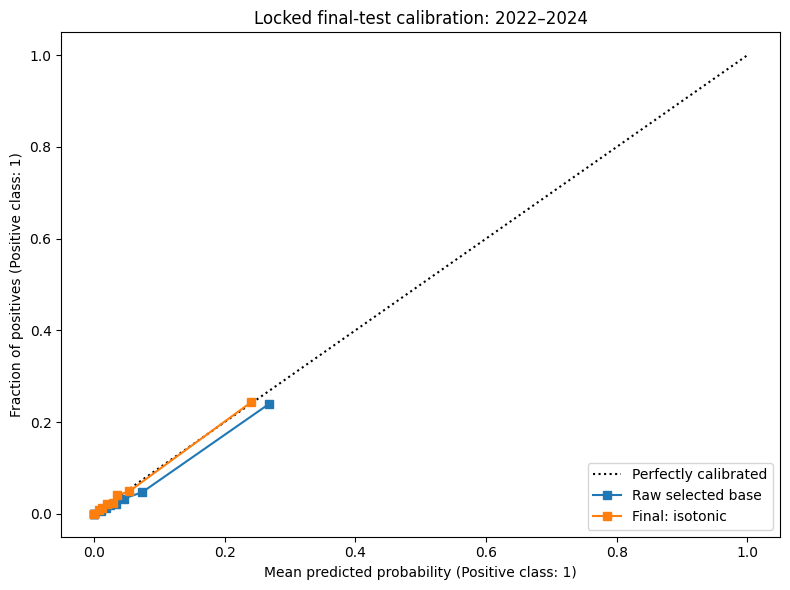

In [25]:
fig, ax = plt.subplots(figsize=(8, 6))

CalibrationDisplay.from_predictions(
    y_test,
    raw_test_probability,
    n_bins=10,
    strategy="quantile",
    name="Raw selected base",
    ax=ax,
)

CalibrationDisplay.from_predictions(
    y_test,
    final_test_probability,
    n_bins=10,
    strategy="quantile",
    name=f"Final: {SELECTED_CALIBRATION_METHOD}",
    ax=ax,
)

ax.set_title("Locked final-test calibration: 2022–2024")
plt.tight_layout()
plt.show()

### Final calibration interpretation

The untouched 2022–2024 final test contained 59,219 reported wildlife-strike incidents, including 2,246 incidents with reported damage, corresponding to a prevalence of 3.79%.

The raw airport-aware XGBoost achieved a Brier score of 0.02893 and log loss of 0.11286. After isotonic calibration, the Brier score improved slightly to 0.02875 and log loss improved slightly to 0.11248. The mean calibrated predicted probability was 0.03773, which was also very close to the observed final-test prevalence of 0.03793.

The calibrated system achieved a PR-AUC of 0.3605 and ROC-AUC of 0.8829, compared with 0.3805 and 0.8837 for the raw model. Therefore, calibration slightly improved absolute probability quality while reducing PR-AUC. This reflects a trade-off between probability calibration and ranking performance rather than an across-the-board improvement.

The final calibration results support retaining isotonic calibration for probability-based simulation because Brier score and log loss both improved on the untouched test set. However, the improvement was modest, and the reduction in PR-AUC should remain visible when reporting model performance.


## 12. Performance by future reporting year

Overall 2022–2024 metrics can hide drift inside the test period. Metrics are therefore reported separately for each year. These are descriptive final-test diagnostics; they are not used for further tuning.

In [26]:
yearly_rows = []

test_indices = df.index[test_mask]
test_probability_series = pd.Series(
    final_test_probability,
    index=test_indices
)

for year, year_df in df.loc[test_mask].groupby("INCIDENT_YEAR"):
    idx = year_df.index
    y_year = year_df[TARGET].astype(int)
    p_year = test_probability_series.loc[idx].to_numpy()

    if y_year.nunique() < 2:
        continue

    yearly_rows.append({
        "INCIDENT_YEAR": int(year),
        **probability_metrics(y_year, p_year),
    })

future_year_metrics = pd.DataFrame(yearly_rows)
future_year_metrics.to_csv(
    OUTPUT_DIR / "final_test_metrics_by_year.csv",
    index=False
)
display(future_year_metrics.round(5))

,INCIDENT_YEAR,n,positives,prevalence,pr_auc,roc_auc,brier_score,log_loss,mean_predicted_probability
0,2022,17223,702,0.04076,0.36322,0.88778,0.03093,0.11894,0.03789
1,2023,19625,721,0.03674,0.36741,0.87803,0.02774,0.11119,0.03757
2,2024,22371,823,0.03679,0.35397,0.88301,0.02796,0.10864,0.03776


Performance remained broadly stable across the three future reporting years. PR-AUC was 0.3632 in 2022, 0.3674 in 2023, and 0.3540 in 2024. ROC-AUC similarly remained within a narrow range of approximately 0.878–0.888.

Probability-quality metrics did not show progressive deterioration. Brier score decreased from 0.03093 in 2022 to 0.02774 in 2023 and 0.02796 in 2024, while log loss decreased from 0.11894 to 0.11119 and 0.10864. Some year-to-year variation is present, particularly the lower 2024 PR-AUC, but there is no evidence of a severe temporal collapse during the final-test period.


## 13. Unseen-airport generalization on the final test

Two flags are shown:

- `unseen_to_base_training`: airport absent from 1990–2018, the period used to fit the underlying model;
- `unseen_to_development`: airport absent from all 1990–2021 development data.

The first directly answers the checklist requirement about airports excluded from model training. The second is a stricter novelty check.

In [27]:
base_training_airports = set(
    df.loc[train_mask, "AIRPORT_ID"].astype("string").dropna().unique()
)
development_airports = set(
    df.loc[development_mask, "AIRPORT_ID"].astype("string").dropna().unique()
)

test_eval = df.loc[
    test_mask,
    ["INDEX_NR", "INCIDENT_YEAR", TARGET, "AIRPORT_ID"]
].copy()
test_eval["probability"] = final_test_probability
test_eval["unseen_to_base_training"] = (
    ~test_eval["AIRPORT_ID"].astype("string").isin(base_training_airports)
)
test_eval["unseen_to_development"] = (
    ~test_eval["AIRPORT_ID"].astype("string").isin(development_airports)
)

airport_generalization_rows = []

for flag in ["unseen_to_base_training", "unseen_to_development"]:
    for value, subset in test_eval.groupby(flag):
        y_subset = subset[TARGET].astype(int)
        if len(subset) == 0 or y_subset.nunique() < 2:
            continue
        airport_generalization_rows.append({
            "definition": flag,
            "group": bool(value),
            **probability_metrics(
                y_subset,
                subset["probability"].to_numpy()
            ),
            "unique_airports": int(subset["AIRPORT_ID"].nunique()),
        })

airport_generalization = pd.DataFrame(
    airport_generalization_rows
)

airport_generalization["baseline_brier"] = (
    airport_generalization["prevalence"]
    * (1 - airport_generalization["prevalence"])
)

airport_generalization["brier_skill_score"] = (
    1
    - airport_generalization["brier_score"]
    / airport_generalization["baseline_brier"]
)

airport_generalization["calibration_in_the_large"] = (
    airport_generalization["mean_predicted_probability"]
    - airport_generalization["prevalence"]
)

airport_generalization.to_csv(
    OUTPUT_DIR / "final_test_unseen_airport_metrics.csv",
    index=False
)
display(airport_generalization.round(5))

,definition,group,n,positives,prevalence,pr_auc,roc_auc,brier_score,log_loss,mean_predicted_probability,unique_airports,baseline_brier,brier_skill_score,calibration_in_the_large
0,unseen_to_base_training,False,58911,2169,0.03682,0.34389,0.88041,0.02834,0.11129,0.03677,1091,0.03546,0.20077,-0.00004
1,unseen_to_base_training,True,308,77,0.25000,0.74905,0.89301,0.10647,0.34046,0.22159,196,0.18750,0.43217,-0.02841
2,unseen_to_development,False,59016,2179,0.03692,0.34546,0.88067,0.02838,0.11139,0.03693,1122,0.03556,0.20185,0.00000
3,unseen_to_development,True,203,67,0.33005,0.76696,0.86540,0.13568,0.42955,0.27262,165,0.22112,0.38638,-0.05743


The final-test unseen-airport subsets were small and had substantially higher damage prevalence than the represented-airport population. Because both PR-AUC and raw Brier score are affected by outcome prevalence, their absolute values should not be compared directly across these groups as if they were on identical distributions.

Among airports absent from the 1990–2018 base-model training period, the observed damage prevalence was 25.0%, compared with a mean calibrated prediction of 22.2%. For airports absent from all 1990–2021 development data, observed prevalence was 33.0% compared with a mean prediction of 27.3%. This indicates some aggregate underprediction for genuinely novel airports.

The unseen-airport results nevertheless retained useful discrimination. Interpretation should therefore focus on the small subgroup sizes, prevalence shift, aggregate underprediction, and historical support rather than treating the larger raw Brier scores alone as evidence of poorer model quality.

## 14. Rare wildlife and aircraft group performance

Rare-group metrics should be interpreted cautiously. PR-AUC is especially unstable when a subgroup contains very few positive cases, so counts and prevalence are always displayed beside the score.

No subgroup is removed because it performs poorly.

In [28]:
def subgroup_probability_table(
    data,
    probabilities,
    feature,
    rare_values=None,
    min_rows=50,
    min_positives=5,
):
    work = data[[feature, TARGET]].copy()
    work["probability"] = np.asarray(probabilities)
    work[feature] = work[feature].astype("string").fillna("<MISSING>")

    rows = []
    for level, subset in work.groupby(feature, dropna=False):
        y = subset[TARGET].astype(int)
        is_rare = (
            str(level) in set(map(str, rare_values or []))
        )

        row = {
            "feature": feature,
            "level": str(level),
            "is_rare_from_development": is_rare,
            "n": int(len(subset)),
            "positives": int(y.sum()),
            "prevalence": float(y.mean()),
        }

        if len(subset) >= min_rows and y.sum() >= min_positives and y.nunique() == 2:
            row.update(probability_metrics(y, subset["probability"]))
        else:
            row.update({
                "pr_auc": np.nan,
                "roc_auc": np.nan,
                "brier_score": np.nan,
                "log_loss": np.nan,
                "mean_predicted_probability": float(
                    subset["probability"].mean()
                ),
            })

        rows.append(row)

    return pd.DataFrame(rows)


rare_subgroup_tables = []

test_data_for_groups = df.loc[test_mask].copy()

for feature in rare_group_definitions:
    rare_subgroup_tables.append(
        subgroup_probability_table(
            test_data_for_groups,
            final_test_probability,
            feature,
            rare_values=rare_group_definitions[feature],
        )
    )

rare_subgroup_metrics = pd.concat(
    rare_subgroup_tables, ignore_index=True
)

rare_subgroup_metrics["level"] = (
    rare_subgroup_metrics["level"].astype("string")
)

development_group_support["level"] = (
    development_group_support["level"].astype("string")
)

rare_subgroup_metrics = rare_subgroup_metrics.merge(
    development_group_support[
        [
            "feature",
            "level",
            "development_records",
            "development_damage_cases",
            "development_damage_prevalence",
            "positive_outcome_support",
        ]
    ],
    on=["feature", "level"],
    how="left",
)

rare_subgroup_metrics.to_csv(
    OUTPUT_DIR / "final_test_rare_group_metrics.csv",
    index=False
)

display(
    rare_subgroup_metrics
    .sort_values(
        ["feature", "is_rare_from_development", "n"],
        ascending=[True, False, False]
    )
    .head(100)
    .round(5)
)

,feature,level,is_rare_from_development,n,positives,prevalence,pr_auc,roc_auc,brier_score,log_loss,mean_predicted_probability,development_records,development_damage_cases,development_damage_prevalence,positive_outcome_support
7,AC_CLASS,C,True,2,0,0.00000,NaN,NaN,NaN,NaN,0.28677,5,3,0.60000,very_low
9,AC_CLASS,Y,True,2,0,0.00000,NaN,NaN,NaN,NaN,0.12007,1,0,0.00000,very_low
5,AC_CLASS,A,False,39548,2091,0.05287,0.35899,0.82663,0.04014,0.15779,0.05212,183812,17626,0.09589,adequate
8,AC_CLASS,Not reported,False,18645,26,0.00139,0.51164,0.97856,0.00090,0.00461,0.00144,72180,233,0.00323,adequate
6,AC_CLASS,B,False,1022,129,0.12622,0.37142,0.76200,0.09586,0.32667,0.14243,3886,800,0.20587,adequate
10,AC_MASS_GROUP,Heavy,False,32913,1230,0.03737,0.22537,0.78012,0.03190,0.13400,0.03707,131267,9126,0.06952,adequate
13,AC_MASS_GROUP,Unknown,False,18677,23,0.00123,0.41290,0.97548,0.00091,0.00470,0.00109,72268,151,0.00209,adequate
11,AC_MASS_GROUP,Light,False,4587,735,0.16024,0.53057,0.82641,0.09964,0.33150,0.16796,23262,6069,0.26090,adequate
12,AC_MASS_GROUP,Medium,False,3042,258,0.08481,0.44710,0.85242,0.05872,0.21125,0.07361,33091,3316,0.10021,adequate
1,WILDLIFE_TYPE,Bird,False,52810,1986,0.03761,0.33786,0.87810,0.02911,0.11369,0.03651,240623,16543,0.06875,adequate


The positive-outcome support analysis adds important context to the subgroup metrics. Most major wildlife and aircraft groups had adequate numbers of reported-damage cases during development. Bats, however, had only 50 development damage cases despite 4,443 total records and therefore received moderate positive-outcome support. Reptiles had only four development damage cases and were classified as very-low support. Aircraft classes C, J, and Y similarly had extremely limited positive-outcome evidence.

These support classifications help distinguish genuinely well-supported subgroup metrics from apparently large categories that contain few positive outcomes. No subgroup was excluded from evaluation; the labels are used only to qualify the strength of the evidence.


## 15. Locked-threshold classification and confusion matrices

These results answer a different question from calibration. They show how the final probability system behaves when converted into yes/no classifications using thresholds selected before the final test.

The maximum-F1 threshold is treated as the main balanced reference for error analysis. The other thresholds remain sensitivity analyses.

In [29]:
final_threshold_rows = []

for threshold_row in locked_thresholds.itertuples():
    metrics = threshold_metrics(
        y_test,
        final_test_probability,
        float(threshold_row.threshold)
    )
    final_threshold_rows.append({
        "rule": threshold_row.rule,
        **metrics,
    })

final_threshold_results = pd.DataFrame(final_threshold_rows)
final_threshold_results.to_csv(
    OUTPUT_DIR / "final_test_locked_threshold_metrics.csv",
    index=False
)
display(final_threshold_results.round(4))

,rule,threshold,precision,recall,f1,f2,tn,fp,fn,tp
0,maximum_validation_f1,0.2000,0.4135,0.4150,0.4142,0.4147,55651,1322,1314,932
1,maximum_validation_f2_sensitivity,0.1053,0.2680,0.5931,0.3691,0.4772,53334,3639,914,1332
2,highest_precision_at_recall_70,0.0763,0.2223,0.6505,0.3314,0.4696,51862,5111,785,1461
3,highest_precision_at_recall_80,0.0342,0.1244,0.8028,0.2153,0.3839,44277,12696,443,1803


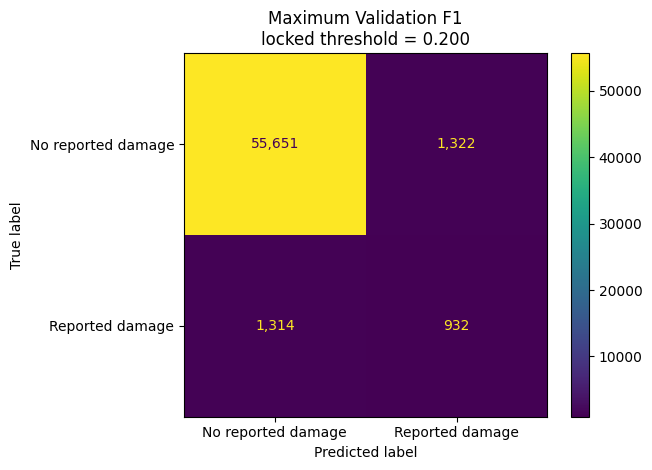

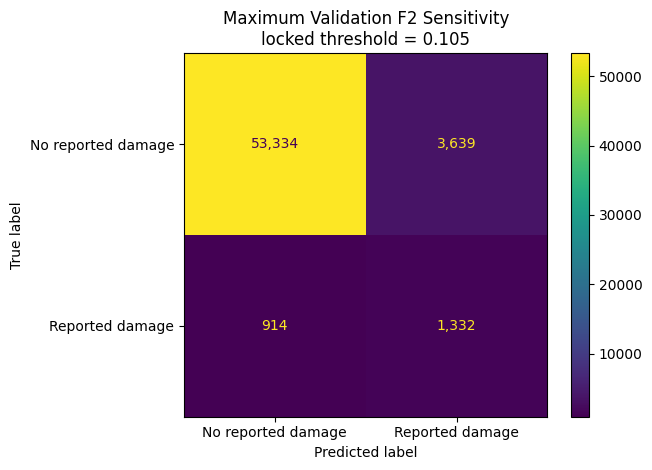

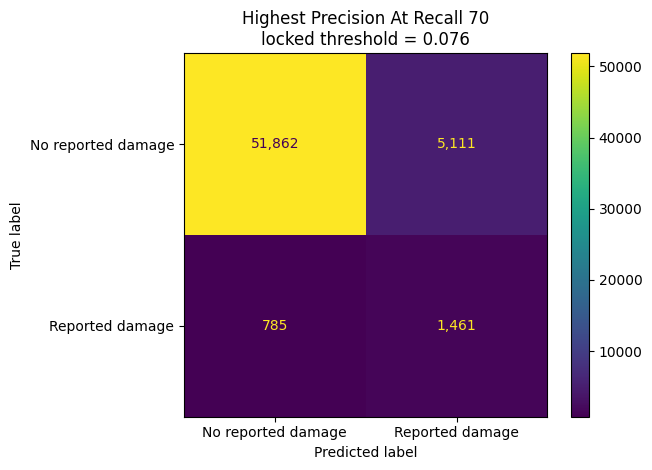

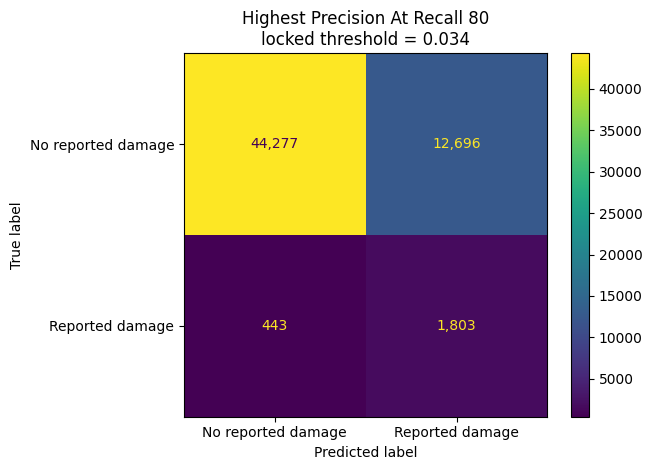

In [30]:
for row in final_threshold_results.itertuples():
    pred = (
        final_test_probability >= float(row.threshold)
    ).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        labels=[0, 1],
        display_labels=["No reported damage", "Reported damage"],
        values_format=",",
    )
    plt.title(
        f"{row.rule.replace('_', ' ').title()}\n"
        f"locked threshold = {row.threshold:.3f}"
    )
    plt.tight_layout()
    plt.show()

The locked maximum-F1 threshold of 0.200 produced the most balanced final-test classification reference, with precision of 0.4135, recall of 0.4150, and F1 of 0.4142. Its confusion matrix contained 932 true positives, 1,314 false negatives, 1,322 false positives, and 55,651 true negatives.

As expected, lowering the threshold increased recall but also produced more false positives. The F2-oriented threshold of 0.1053 increased recall to 59.3% while reducing precision to 26.8%. The threshold originally selected to target at least 70% validation recall achieved 65.1% recall on the future test, showing that threshold behavior did not transfer perfectly over time. The 80%-recall validation threshold retained approximately 80.3% recall on the test set but reduced precision to 12.4% and generated 12,696 false positives.

These results illustrate why no single threshold should be described as universally optimal. The appropriate operating point depends on the relative cost of missing a damaging strike versus generating a false alert. In this project, the continuous calibrated probability remains the principal downstream output, while threshold results are reported to make this trade-off transparent.


## 16. False-positive and false-negative characterization

Error analysis uses the locked maximum-F1 reference threshold. It reports error composition by:

- wildlife group;
- aircraft class / mass group;
- phase of flight;
- airport;
- reporting year.

The purpose is to identify where the model tends to miss damaging incidents or issue more false alarms. These are descriptive model-behavior patterns, not causal effects.

In [31]:
main_threshold = float(
    locked_thresholds.loc[
        locked_thresholds["rule"].eq("maximum_validation_f1"),
        "threshold"
    ].iloc[0]
)

error_frame = df.loc[test_mask].copy()
error_frame["probability"] = final_test_probability
error_frame["prediction"] = (
    error_frame["probability"] >= main_threshold
).astype(int)

error_frame["error_type"] = np.select(
    [
        (error_frame[TARGET].eq(1) & error_frame["prediction"].eq(0)),
        (error_frame[TARGET].eq(0) & error_frame["prediction"].eq(1)),
        (error_frame[TARGET].eq(1) & error_frame["prediction"].eq(1)),
        (error_frame[TARGET].eq(0) & error_frame["prediction"].eq(0)),
    ],
    ["false_negative", "false_positive", "true_positive", "true_negative"],
    default="unknown",
)

display(error_frame["error_type"].value_counts())

error_type
true_negative     55651
false_positive     1322
false_negative     1314
true_positive       932
Name: count, dtype: int64

In [32]:
error_dimensions = [
    c for c in [
        "WILDLIFE_TYPE",
        "AC_CLASS",
        "AC_MASS_GROUP",
        "PHASE_OF_FLIGHT",
        "AIRPORT_ID",
        "INCIDENT_YEAR",
    ]
    if c in error_frame.columns
]

error_tables = []

for feature in error_dimensions:
    temp = (
        error_frame
        .groupby([feature, "error_type"], dropna=False)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    for needed in [
        "false_negative", "false_positive",
        "true_positive", "true_negative"
    ]:
        if needed not in temp.columns:
            temp[needed] = 0

    temp["actual_positive"] = (
        temp["false_negative"] + temp["true_positive"]
    )
    temp["actual_negative"] = (
        temp["false_positive"] + temp["true_negative"]
    )

    temp["false_negative_rate_within_actual_positive"] = np.where(
        temp["actual_positive"] > 0,
        temp["false_negative"] / temp["actual_positive"],
        np.nan,
    )
    temp["false_positive_rate_within_actual_negative"] = np.where(
        temp["actual_negative"] > 0,
        temp["false_positive"] / temp["actual_negative"],
        np.nan,
    )

    temp.insert(0, "dimension", feature)
    temp = temp.rename(columns={feature: "level"})
    error_tables.append(temp)

error_analysis = pd.concat(error_tables, ignore_index=True)
error_analysis.to_csv(
    OUTPUT_DIR / "final_test_error_analysis.csv",
    index=False
)

display(
    error_analysis
    .sort_values(
        ["dimension", "false_negative"],
        ascending=[True, False]
    )
    .head(100)
    .round(4)
)

error_type,dimension,level,false_negative,false_positive,true_negative,true_positive,actual_positive,actual_negative,false_negative_rate_within_actual_positive,false_positive_rate_within_actual_negative
5,AC_CLASS,A,1244,1164,36293,847,2091,37457,0.5949,0.0311
6,AC_CLASS,B,60,136,757,69,129,893,0.4651,0.1523
8,AC_CLASS,Not reported,10,21,18598,16,26,18619,0.3846,0.0011
7,AC_CLASS,C,0,1,1,0,0,2,NaN,0.5000
9,AC_CLASS,Y,0,0,2,0,0,2,NaN,0.0000
10,AC_MASS_GROUP,Heavy,932,529,31154,298,1230,31683,0.7577,0.0167
11,AC_MASS_GROUP,Light,243,629,3223,492,735,3852,0.3306,0.1633
12,AC_MASS_GROUP,Medium,125,150,2634,133,258,2784,0.4845,0.0539
13,AC_MASS_GROUP,Unknown,14,14,18640,9,23,18654,0.6087,0.0008
1312,AIRPORT_ID,ZZZZ,340,300,8968,168,508,9268,0.6693,0.0324


### Error-analysis interpretation

At the locked maximum-F1 threshold, the final test produced 1,314 false negatives and 1,322 false positives, alongside 932 true positives and 55,651 true negatives. The similar numbers of false negatives and false positives are consistent with the use of an F1-oriented threshold, which seeks a balance between precision and recall rather than prioritizing one error type.

Aircraft class A contributed the largest absolute number of both false negatives and false positives, with 1,244 and 1,164 respectively. Heavy aircraft contributed 932 false negatives, whereas light aircraft contributed 629 false positives. These raw counts partly reflect how frequently these categories occur and therefore should not be interpreted as evidence that the categories themselves cause errors.

Airport-level counts were especially concentrated in the `ZZZZ` airport code, which accounted for 340 false negatives and 300 false positives. Because the interpretation of `ZZZZ` should follow the FAA coding documentation established in the earlier data-understanding/cleaning stages, it should not be treated as an ordinary named airport without confirming that mapping.

The error analysis therefore indicates that classification mistakes are not uniformly distributed across scenario groups. Interpretation should rely on both error counts and within-group error rates, with cautious treatment of categories that have limited support.


## 17. Historical support attached to final-test observations

The support measure is applied to final-test records only for diagnostic purposes. Downstream simulation should use the exported 1990–2021 support tables to evaluate user-entered scenarios.

In [33]:
joint_lookup = joint_support.set_index(
    joint_support_features
)["historical_count"]

support_eval = df.loc[
    test_mask,
    ["INDEX_NR"] + joint_support_features
].copy()

for c in joint_support_features:
    support_eval[c] = (
        support_eval[c].astype("string").fillna("<MISSING>")
    )

keys = pd.MultiIndex.from_frame(
    support_eval[joint_support_features]
)
support_eval["joint_historical_count"] = (
    joint_lookup.reindex(keys).fillna(0).to_numpy()
)
support_eval["joint_support_tier"] = (
    support_eval["joint_historical_count"].map(support_tier)
)

support_eval["observed_damage"] = y_test.to_numpy()
support_eval["probability"] = final_test_probability

support_performance_rows = []
for tier, subset in support_eval.groupby("joint_support_tier"):
    y = subset["observed_damage"].astype(int)
    row = {
        "joint_support_tier": tier,
        "n": len(subset),
        "positives": int(y.sum()),
        "prevalence": float(y.mean()),
        "mean_joint_historical_count": float(
            subset["joint_historical_count"].mean()
        ),
    }
    if len(subset) >= 50 and y.sum() >= 5 and y.nunique() == 2:
        row.update(
            probability_metrics(y, subset["probability"].to_numpy())
        )
    support_performance_rows.append(row)

support_performance = pd.DataFrame(support_performance_rows)

support_performance["baseline_brier"] = (
    support_performance["prevalence"]
    * (1 - support_performance["prevalence"])
)

support_performance["brier_skill_score"] = (
    1
    - support_performance["brier_score"]
    / support_performance["baseline_brier"]
)

support_performance["calibration_in_the_large"] = (
    support_performance["mean_predicted_probability"]
    - support_performance["prevalence"]
)

support_performance.to_csv(
    OUTPUT_DIR / "final_test_performance_by_support_tier.csv",
    index=False
)
display(support_performance.round(5))

,joint_support_tier,n,positives,prevalence,mean_joint_historical_count,pr_auc,roc_auc,brier_score,log_loss,mean_predicted_probability,baseline_brier,brier_skill_score,calibration_in_the_large
0,high,51048,1496,0.02931,3365.36370,0.29003,0.87140,0.02378,0.09626,0.02819,0.02845,0.16412,-0.00111
1,low,1882,196,0.10414,11.30128,0.57027,0.88278,0.06204,0.21710,0.10696,0.09330,0.33502,0.00282
2,moderate,5201,418,0.08037,53.35858,0.45137,0.88226,0.05474,0.19595,0.09001,0.07391,0.25934,0.00964
3,unseen,292,29,0.09932,0.00000,0.46022,0.86017,0.06764,0.23202,0.11528,0.08945,0.24386,0.01597
4,very_low,796,107,0.13442,2.45477,0.52546,0.84713,0.08470,0.31612,0.11608,0.11635,0.27201,-0.01834


Most final-test observations occurred in historically well-supported scenario combinations, with 51,048 of 59,219 observations classified as high support. Lower-support groups differed substantially from the high-support population, particularly in damage prevalence.

Because raw Brier score and PR-AUC are influenced by prevalence, their absolute values should not be interpreted as directly comparable measures of reliability across support tiers. Instead, support-tier assessment should consider sample size, positive-case count, Brier skill relative to each subgroup's prevalence baseline, and the difference between mean predicted probability and observed prevalence.

The support analysis therefore shows that low-support and unseen scenarios represent distributionally different and less well-evidenced situations, even though the model may still retain predictive skill within them. Historical-support tiers should consequently be presented as evidence-strength warnings rather than as proof that low-support predictions are automatically inaccurate.


## 18. Monte Carlo trustworthiness decision gate

The checklist requires a direct decision about whether the probabilities are trustworthy enough for downstream Monte Carlo use.

There is no universal numeric cutoff that makes a probability model automatically simulation-ready. The decision should combine:

1. **discrimination:** final PR-AUC remains meaningfully above final damage prevalence;
2. **probability quality:** Brier score / log loss are competitive with the raw base and the calibration curve is not grossly distorted;
3. **temporal stability:** performance does not collapse across 2022, 2023, or 2024;
4. **geographic stability:** unseen-airport performance remains usable and is not radically worse than seen-airport performance;
5. **rare-group stability:** low-support groups are identified and warned rather than silently treated as equally reliable;
6. **historical support:** downstream scenarios can be labelled as high/moderate/low/very-low/unseen support;
7. **scope communication:** simulation remains conditional on a reported strike and is not a physical impact or strike-occurrence model.

A defensible outcome can be:

- **PASS WITH WARNINGS:** probabilities are adequate for scenario-based Monte Carlo, provided support warnings and scope limitations remain visible;
- **RESTRICT:** use the model only for adequately supported scenarios / groups;
- **DO NOT USE FOR MONTE CARLO YET:** probability calibration or generalization is too weak.

The notebook deliberately does not invent a pass/fail result before the final outputs are available.

In [34]:
# Evidence table to support the manual academic decision.
final_metrics_row = final_test_probability_comparison.iloc[-1]

trust_evidence = pd.DataFrame([
    {
        "criterion": "Final discrimination",
        "evidence": (
            f"PR-AUC={final_metrics_row['pr_auc']:.4f}; "
            f"prevalence={final_metrics_row['prevalence']:.4f}"
        ),
        "interpretation_required": True,
    },
    {
        "criterion": "Final probability quality",
        "evidence": (
            f"Brier={final_metrics_row['brier_score']:.4f}; "
            f"log loss={final_metrics_row['log_loss']:.4f}"
        ),
        "interpretation_required": True,
    },
    {
        "criterion": "Temporal stability",
        "evidence": "See final_test_metrics_by_year.csv",
        "interpretation_required": True,
    },
    {
        "criterion": "Unseen-airport stability",
        "evidence": "See final_test_unseen_airport_metrics.csv",
        "interpretation_required": True,
    },
    {
        "criterion": "Rare-group stability",
        "evidence": "See final_test_rare_group_metrics.csv",
        "interpretation_required": True,
    },
    {
        "criterion": "Historical support coverage",
        "evidence": "See final_test_performance_by_support_tier.csv",
        "interpretation_required": True,
    },
])

trust_evidence.to_csv(
    OUTPUT_DIR / "monte_carlo_trust_decision_evidence.csv",
    index=False
)
display(trust_evidence)

,criterion,evidence,interpretation_required
0,Final discrimination,PR-AUC=0.3605; prevalence=0.0379,True
1,Final probability quality,Brier=0.0287; log loss=0.1125,True
2,Temporal stability,See final_test_metrics_by_year.csv,True
3,Unseen-airport stability,See final_test_unseen_airport_metrics.csv,True
4,Rare-group stability,See final_test_rare_group_metrics.csv,True
5,Historical support coverage,See final_test_performance_by_support_tier.csv,True


### Final decision

**Decision:** **PASS WITH WARNINGS**

The locked final probability system uses the airport-aware XGBoost candidate with isotonic calibration. On the untouched 2022–2024 test period, it achieved a PR-AUC of 0.3605, Brier score of 0.02875, and log loss of 0.11248, at an observed damage prevalence of 3.79%.

Calibration slightly improved absolute probability quality relative to the raw base model: Brier score decreased from 0.02893 to 0.02875 and log loss decreased from 0.11286 to 0.11248. However, PR-AUC decreased from 0.3805 to 0.3605, so the benefit of calibration should be understood as improved probability reliability rather than improved classification ranking.

Future-year performance remained broadly stable across 2022–2024, with no severe temporal collapse, although PR-AUC was somewhat lower in 2024. Airports absent from base-model training showed useful discrimination and positive Brier skill relative to their own prevalence baselines, but these subsets were small and had substantially higher damage prevalence than represented airports. The calibrated probabilities also showed aggregate underprediction for unseen airports, particularly for airports absent from all 1990–2021 development data.

Rare and historically unsupported scenario combinations did not show a simple collapse in predictive skill. However, they were represented by fewer observations, differed substantially in damage prevalence, and in several cases showed larger calibration-in-the-large deviations. These groups should therefore receive stronger uncertainty and historical-support warnings rather than being described as automatically unreliable.

The PASS WITH WARNINGS classification is a structured analytical judgment based on the combined validation evidence rather than the result of a universal numerical acceptance threshold.


## 19. Save the canonical final probability artifact

The serialized object saved here is the exact probability system evaluated on the final test:

- its preprocessing was fitted in Notebook 05;
- its base estimator was fitted on 1990–2018;
- if calibration was selected, its calibrator was fitted on 2019–2021;
- no component is refitted after viewing 2022–2024.

This artifact is the source of truth for Notebook 10 and the interface.

In [35]:
FINAL_MODEL_PATH = FINAL_MODEL_DIR / "final_calibrated_pipeline.joblib"

joblib.dump(final_probability_model, FINAL_MODEL_PATH)

final_model_manifest = pd.DataFrame([{
    "artifact": FINAL_MODEL_PATH.name,
    "path": str(FINAL_MODEL_PATH),
    "selected_base_candidate": SELECTED_BASE_KEY,
    "selected_calibration_method": SELECTED_CALIBRATION_METHOD,
    "feature_set": (
        "airport_aware"
        if SELECTED_BASE_KEY.endswith("airport_aware")
        else "extended_geographic"
    ),
    "n_input_features": len(SELECTED_FEATURES),
    "base_fit_period": "1990–2018",
    "calibration_fit_period": (
        "none" if SELECTED_CALIBRATION_METHOD == "raw" else "2019–2021"
    ),
    "final_test_period": "2022–2024",
    "file_size_mb": FINAL_MODEL_PATH.stat().st_size / 1024**2,
    "purpose": "Canonical probability model for simulation and interface",
}])

final_model_manifest.to_csv(
    OUTPUT_DIR / "final_model_manifest.csv",
    index=False
)

with open(
    OUTPUT_DIR / "final_model_features.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        {
            "selected_base_candidate": SELECTED_BASE_KEY,
            "selected_calibration_method": SELECTED_CALIBRATION_METHOD,
            "features": SELECTED_FEATURES,
            "target": TARGET,
            "seed": SEED,
        },
        f,
        indent=2,
    )

display(final_model_manifest)

,artifact,path,selected_base_candidate,selected_calibration_method,feature_set,n_input_features,base_fit_period,calibration_fit_period,final_test_period,file_size_mb,purpose
0,final_calibrated_pipeline.joblib,c:\Users\davis\Programing\MDA_programs\Capston...,xgboost__airport_aware,isotonic,airport_aware,20,1990–2018,2019–2021,2022–2024,1.880416,Canonical probability model for simulation and...


## 20. Save validation metadata and output inventory

Notebook 06 exports machine-readable evidence so later notebooks do not need to reconstruct the validation decisions.

The key persistent outputs are:

- geographic validation and model decision;
- calibration-fold metrics and forward predictions;
- locked calibrated thresholds;
- final test metrics overall and by subgroup;
- false-positive / false-negative analysis;
- historical support tables;
- rare-group definitions;
- final-model manifest and feature list;
- canonical `models/final/final_calibrated_pipeline.joblib`.

In [37]:
validation_metadata = {
    "seed": SEED,
    "base_training_period": [1990, 2018],
    "validation_calibration_period": [2019, 2021],
    "final_test_period": [2022, 2024],
    "selected_base_candidate": SELECTED_BASE_KEY,
    "selected_calibration_method": SELECTED_CALIBRATION_METHOD,
    "final_test_used_for_model_selection": False,
    "final_test_used_for_calibration_selection": False,
    "final_test_used_for_threshold_selection": False,
    "threshold_rules": locked_thresholds["rule"].tolist(),
    "historical_support_period": [1990, 2021],
    "joint_support_features": joint_support_features,
    "rare_group_definition": {
        "count_threshold": RARE_COUNT_THRESHOLD,
        "share_threshold": RARE_SHARE_THRESHOLD,
    },
}

with open(
    OUTPUT_DIR / "validation_metadata.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(validation_metadata, f, indent=2)

artifact_purposes = {
    "geographic_generalization_validation.csv":
        "2019–2021 all/unseen-airport candidate comparison",
    "geographic_model_decision.csv":
        "Pre-test geographic candidate decision",
    "forward_calibration_fold_metrics.csv":
        "Forward-year calibration-fold metrics",
    "forward_calibration_predictions.csv":
        "Forward probabilities for calibration and threshold selection",
    "calibration_method_selection.csv":
        "Pre-test calibration-method decision",
    "locked_calibrated_thresholds.csv":
        "Pre-test threshold policies",
    "pretest_locked_decisions.csv":
        "Audit proof that decisions were locked before final test",
    "historical_marginal_support.csv":
        "Marginal historical scenario support",
    "historical_joint_support.csv":
        "Joint core-context historical support",
    "rare_group_definitions.csv":
        "Development-defined rare wildlife/aircraft groups",
    "final_test_probability_metrics.csv":
        "Raw versus final probability metrics on 2022–2024",
    "final_test_metrics_by_year.csv":
        "Future-year stability",
    "final_test_unseen_airport_metrics.csv":
        "Geographic generalization on final test",
    "final_test_rare_group_metrics.csv":
        "Rare wildlife/aircraft group performance",
    "final_test_locked_threshold_metrics.csv":
        "Final classification behavior at locked thresholds",
    "final_test_error_analysis.csv":
        "False-positive/false-negative patterns",
    "final_test_performance_by_support_tier.csv":
        "Model behavior by historical support",
    "monte_carlo_trust_decision_evidence.csv":
        "Evidence table for simulation decision gate",
    "final_model_manifest.csv":
        "Canonical model artifact metadata",
    "final_model_features.json":
        "Exact downstream model input list",
    "validation_metadata.json":
        "Locked validation design and decisions",
    "validation_unseen_airport_diagnostic.csv":
        "Composition and damage prevalence of 2019–2021 unseen airports",
    "development_group_outcome_support.csv":
        "Development counts and positive-damage support for subgroup evaluation",
}

inventory_rows = []
for name, purpose in artifact_purposes.items():
    path = OUTPUT_DIR / name
    if path.exists():
        inventory_rows.append({
            "artifact": name,
            "file_size_mb": path.stat().st_size / 1024**2,
            "purpose": purpose,
        })

if FINAL_MODEL_PATH.exists():
    inventory_rows.append({
        "artifact": str(FINAL_MODEL_PATH.relative_to(ROOT)),
        "file_size_mb": FINAL_MODEL_PATH.stat().st_size / 1024**2,
        "purpose": "Canonical final calibrated probability pipeline",
    })

output_inventory = pd.DataFrame(inventory_rows)
output_inventory.to_csv(
    OUTPUT_DIR / "notebook06_output_inventory.csv",
    index=False
)
display(output_inventory.round(3))

,artifact,file_size_mb,purpose
0,geographic_generalization_validation.csv,0.001,2019–2021 all/unseen-airport candidate comparison
1,geographic_model_decision.csv,0.000,Pre-test geographic candidate decision
2,forward_calibration_fold_metrics.csv,0.001,Forward-year calibration-fold metrics
3,forward_calibration_predictions.csv,1.816,Forward probabilities for calibration and thre...
4,calibration_method_selection.csv,0.001,Pre-test calibration-method decision
5,locked_calibrated_thresholds.csv,0.001,Pre-test threshold policies
6,pretest_locked_decisions.csv,0.000,Audit proof that decisions were locked before ...
7,historical_marginal_support.csv,0.126,Marginal historical scenario support
8,historical_joint_support.csv,0.201,Joint core-context historical support
9,rare_group_definitions.csv,0.000,Development-defined rare wildlife/aircraft groups


## 21. Interpretation and hand-off

The validation stage retained the airport-aware XGBoost as the canonical base candidate. The extended-geographic alternative showed slightly stronger PR-AUC on the small 2019–2021 unseen-airport subset, but it did not improve Brier score and the subset did not meet the predefined support requirement for replacing the primary model.

**Isotonic calibration** was selected using forward-year evidence within 2019–2021. Its improvement over the raw probabilities was modest: it achieved the lowest Brier score, while raw probabilities retained a slightly lower log loss and stronger PR-AUC. On the untouched 2022–2024 final test, isotonic calibration slightly improved both Brier score and log loss, supporting its use when absolute probability quality is more important than ranking alone.

Final-test performance remained reasonably stable across 2022, 2023, and 2024, with no severe temporal collapse. Generalization to previously unseen airports remained promising in discrimination terms and retained positive Brier skill relative to subgroup prevalence baselines. However, the unseen-airport samples were small, had substantially higher damage prevalence than represented airports, and showed aggregate underprediction, especially for airports absent from the full 1990–2021 development population.

Historical-support analysis showed that most final-test incidents occurred in well-supported scenario combinations. Lower-support and unseen combinations differed considerably in sample size and damage prevalence, but did not exhibit a simple monotonic decline in Brier skill. Historical support should therefore be interpreted primarily as an evidence-strength indicator: low-support scenarios warrant greater caution because fewer comparable historical observations are available, not because the model is automatically inaccurate in those cases.

Taken together, the evidence supports a PASS WITH WARNINGS decision for Monte Carlo use. The calibrated probability system is sufficiently stable for scenario-based consequence simulation, provided that downstream applications preserve historical-support warnings, communicate uncertainty, and restrict interpretation to reported wildlife strikes.

### Handoff to Notebook 09

Explainability should use the exact canonical final model and investigate whether the airport-aware model depends excessively on individual airport identities. Its explanations should also be compared with the statistical associations identified in Notebook 04.

### Handoff to Notebook 10

Monte Carlo simulation should load the saved `final_calibrated_pipeline.joblib` and the feature/support metadata exported by this notebook. It should use the calibrated continuous damage probability directly rather than rebuilding preprocessing, retraining the model, or hard-coding probabilities.

## 22. Limitations

- The analysis remains conditional on a **reported wildlife strike**.
- FAA wildlife-strike reports are observational; model behavior and associations are not causal effects.
- Reporting practice, field completeness, aircraft fleets, wildlife composition, and strike circumstances may change over time.
- Calibration can correct systematic probability distortion observed in development data, but it cannot eliminate future distribution shift.
- Airport-held-out evidence does not guarantee performance at every new airport, especially when scenario combinations are historically sparse.
- Rare-group metrics can be unstable because few positive cases produce high sampling variability.
- Historical-support counts indicate data coverage, not physical plausibility, causal risk, or statistical certainty.
- Threshold references are analytical summaries and are not operational safety recommendations.
- The final base estimator is intentionally not refit after the 2022–2024 assessment because that would create an untested model.
- Monte Carlo sampling propagates the fitted probability estimate; it does not by itself represent model uncertainty, reporting bias, or physical impact mechanics.

## References for calibration and evaluation choices

- Brier, G. W. (1950). Verification of forecasts expressed in terms of probability. *Monthly Weather Review, 78*(1), 1–3.
- Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. *Proceedings of ICML*.
- Zadrozny, B., & Elkan, C. (2002). Transforming classifier scores into accurate multiclass probability estimates. *Proceedings of KDD*.
- Davis, J., & Goadrich, M. (2006). The relationship between Precision-Recall and ROC curves. *Proceedings of ICML*.
- Saito, T., & Rehmsmeier, M. (2015). The Precision-Recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3).